# Simulacion Monte Carlo
- Generar cientos/ miles de escenarios de modelos dnode oscilen las variables
- Cada variable del modelo puede ser potencialmente una distribucion de probabilidad
- Durante el proceso de simulacion las distribuciones se samplean aleatoriamente
- De esta forma el modelo se recalcula cientos/miles de veces, generando un resultado tambien en forma de distribucion

## Muestras y Distribuciones Basicas

In [81]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import numpy as np
%matplotlib inline

In [2]:
# Genmeracion de muestras
print('Muestras:')
print(np.random.normal(100,10))
print(np.random.normal(100,10))
print(np.random.normal(100,10))
print(np.random.normal(100,10))
print(np.random.normal(100,10))

Muestras:
122.63891863424462
94.01790027179516
98.82968399611582
105.25105578805088
87.30253073851644


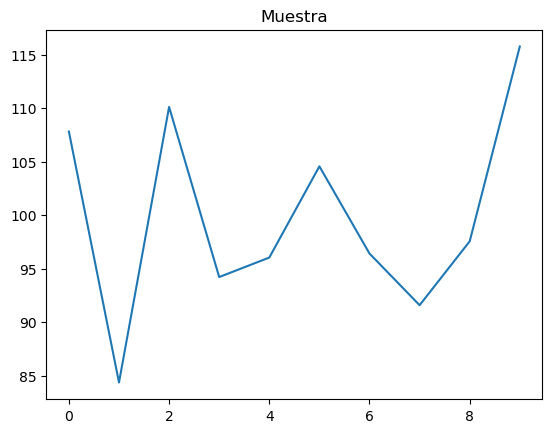

In [3]:
# Muestras de una dsitribucion normal
# Visualizacion
muestra = []

muestra.append(np.random.normal(100,10))
muestra.append(np.random.normal(100,10))
muestra.append(np.random.normal(100,10))
muestra.append(np.random.normal(100,10))
muestra.append(np.random.normal(100,10))
muestra.append(np.random.normal(100,10))
muestra.append(np.random.normal(100,10))
muestra.append(np.random.normal(100,10))
muestra.append(np.random.normal(100,10))
muestra.append(np.random.normal(100,10))

plt.plot(np.arange(0, 10, 1).tolist(), muestra)
plt.title('Muestra')
plt.show()

In [4]:
# Generar un array de mil muestras

muestras = []
rango_muestra = 1000

for i in range(1, rango_muestra):
    muestras.append(np.random.normal(100, 10))

In [5]:
muestras[:5]

[94.72752482785683,
 118.96322625438299,
 102.5170583626346,
 116.2944613944711,
 94.17997676370366]

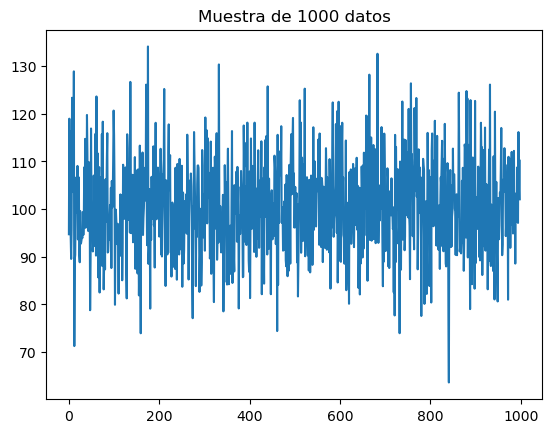

In [6]:
# Grafico
plt.plot(np.arange(0, rango_muestra-1, 1).tolist(), muestras)
plt.title('Muestra de 1000 datos')
plt.show()

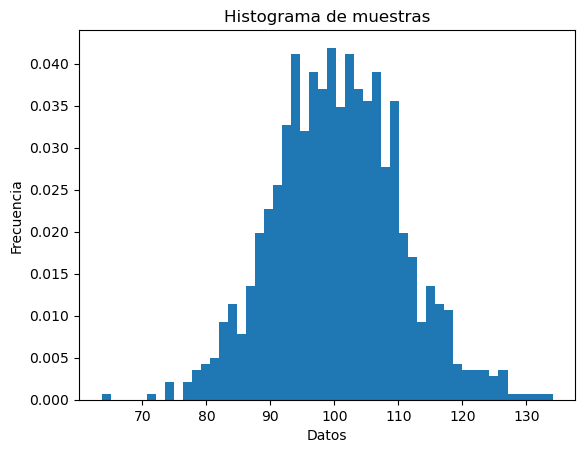

In [7]:
# Generacion de histograma
plt.hist(muestras, density=True, bins=50)
plt.title('Histograma de muestras')
plt.xlabel('Datos')
plt.ylabel('Frecuencia')
plt.show()

## Tipo de dsitribucion lognormal

In [8]:
# Lognormal
media = 3.
sigma = 1.
smp = np.random.lognormal (media, sigma, 1000)

In [9]:
smp

array([  3.28334161,  16.07271719,  28.24724185,   3.35030489,
        41.89964114,  23.82071364,  23.03670271,  20.53441655,
         8.27667504,  16.31976347, 161.74131904,  28.13584621,
        37.10283834,  46.40098291,  35.95518964,  21.92868298,
         6.07294718,   6.40830443,   7.5831288 ,   8.18295218,
         4.41327903,  10.09508005,  19.11501258,   8.95104339,
         4.51196231,   3.43181037,  24.27346162,  14.6901741 ,
       138.012406  ,  28.10652845,   5.18987927,   2.04071257,
        23.52957003,  39.68065727, 260.3775242 ,  12.89369662,
        43.14890067,   8.50307099,  17.44330814,  25.15389767,
        41.23528162,  34.27974142,  12.74350646,  77.4087864 ,
        36.56187127,  39.03306038,  85.21946376,   3.93121478,
        12.04900653, 112.31426176,  40.19391562,   8.38793592,
         5.80736456,   6.6342514 ,  15.2438717 ,  67.36202312,
        29.13725837,  80.78694871,  22.38233026,   2.077489  ,
        27.10683784,  19.63898896,   9.20296701, 129.85

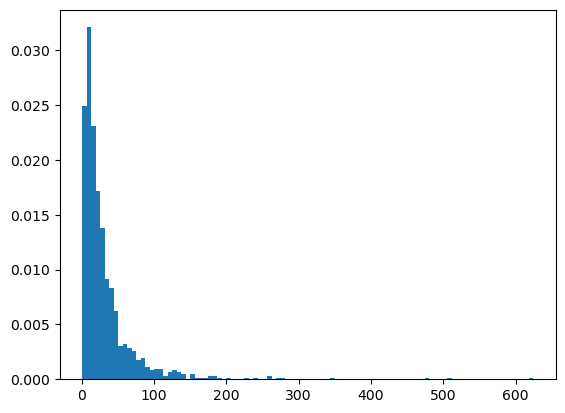

In [ ]:
# grafico de distribucion
count, bins, ignored = plt.hist(smp, 100, density=True, align='mid')
plt.show() 

## Insights
- Cada variable de tu modelo puede ser una distribucion
- Existe decenas de distribuciones disponibles: Continuas y Discretas
- Discretas: Cuentas cosas - Poissonm, Binomial
- Continuas: Rangos ($, tiempo, duracion) - Normal, Lognormal, Welbull, Triangular, PERT, Uniforme

## Modelelo de Presupuesto de Costos
- Se generaran algunas variables para el calculo de un presupuesto simple
- Cada variable se suimara con la siguiente y sera una distribucion triangular 100,150,300
- Esto quiere decir que para cada uno de los conceptos se tendra una varible qie oscila de 100 a 300, para cada escenario

In [26]:
# Variables de configuracion
num_simulations = 10000
max_num_rolls = 1000
bet = 1

# Variables del presupuesto
costo_estudios = 0
costo_diseño = 0
costo_ingenieria = 0
costo_implementacion = 0
costo_pruebas = 0
costo_aceptacion = 0
costo_referencia = 900

In [12]:
# Se generara una funcion "rueda los datos" - es decir saca una muestra de todas las distribuciones simultaneas
# Se incluye la distribucion para cada variable
def roll_dice():
    costo_estudios = np.random.triangular(100, 150, 300)
    costo_diseño = np.random.triangular(100, 150, 300)
    costo_ingenieria = np.random.triangular(100, 150, 300)
    costo_implementacion = np.random.triangular(100, 150, 300)
    costo_pruebas = np.random.triangular(100, 150, 300)
    costo_aceptacion = np.random.triangular(100, 150, 300)

    return costo_estudios, costo_diseño, costo_ingenieria, costo_implementacion, costo_pruebas, costo_aceptacion

In [17]:
# Prueba 1 interacion del prersupuesto
a = roll_dice()

# Se ve como retorna valores en un array
print(a[0],a[1],a[2],a[3],a[4],a[5])

269.50437426416136 173.5493156826951 227.50955847804698 238.138169258944 109.53073554876117 127.85019880989275


In [ ]:
# Inputs
num_simulations = 1000
max_num_rolls = 1000

# Tracking
end_balance = []

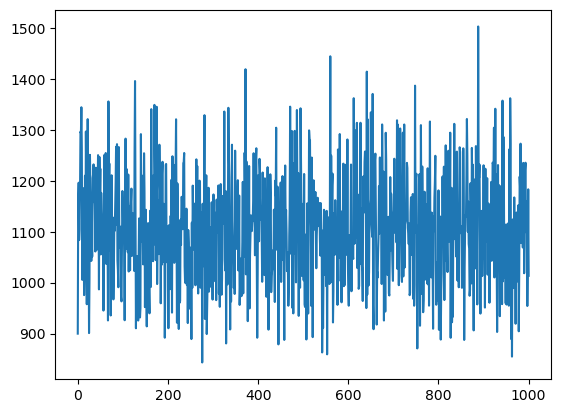

In [21]:
# Ciclo for que corre la simulacion de numeros deseados
for i in range(num_simulations):
    balance = [900]
    num_rolls = [0]

    # Corremos las 1000 veces
    while num_rolls[-1] < max_num_rolls:
        iter = roll_dice()
        # Obtiene el costo total
        costo_total = iter[0] + iter[1] + iter[2] + iter[3] + iter[4] + iter[5]
        balance.append(costo_total)
        num_rolls.append(num_rolls[-1] + 1)

# Graficasmos la muestra
plt.plot(num_rolls, balance)
plt.show()

In [22]:
# Sacamos la media
np.mean(balance)

np.float64(1106.1627091558755)

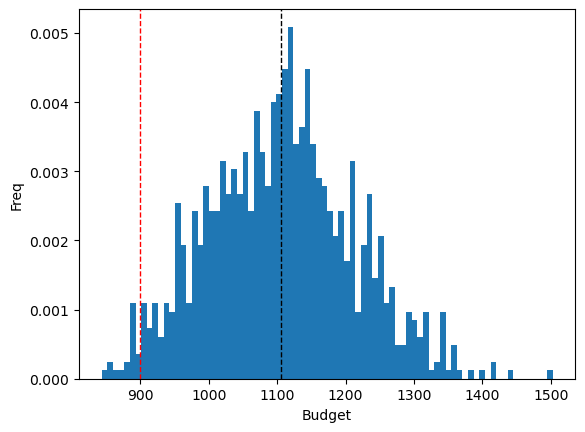

In [28]:
# Generamos el histograna
np.random.seed(42)
plt.hist(balance, density=True, bins=80)
plt.ylabel('Freq')
plt.xlabel('Budget')
plt.axvline(np.mean(balance), color='k', linestyle='dashed', linewidth=1)
plt.axvline(costo_referencia, color='r', linestyle='dashed', linewidth=1)
plt.show()

In [29]:
# Numero de muestras
print('Numero de muestra: ', balance.__len__())
total_muestras = balance.__len__()

Numero de muestra:  1001


In [30]:
# Genera una lista con las muestras menores al costo de referencia en costo_ok
costo_ok = [x for x in balance if x < costo_referencia]

In [31]:
costo_ok

[892.0137415250892,
 889.3641268927651,
 843.4298321714714,
 899.2197350610638,
 880.7814461432057,
 891.9581900996861,
 878.9143785231443,
 887.656733084144,
 888.5538046911478,
 893.1463111437234,
 863.096063802431,
 859.4023204108403,
 871.0053633836932,
 888.3474384866178,
 891.8564113989081,
 887.6177369336503,
 889.5924264630706,
 854.9569065089439]

In [32]:
# Probabilidad de que sea un total menor al costo de referencia
num_costo_ok = costo_ok.__len__()
prob_costo_ref = num_costo_ok / total_muestras
print(f'La probabilidad de que el costo sea menor al costo de referencia es: {prob_costo_ref:.2f} %')

La probabilidad de que el costo sea menor al costo de referencia es: 0.02 %


In [33]:
num_costo_ok

18

In [35]:
# Array de valores menores al costo de referencia
costo_ok[:5]

[892.0137415250892,
 889.3641268927651,
 843.4298321714714,
 899.2197350610638,
 880.7814461432057]

In [39]:
# Percentiles
for i in range (0, 100, 5):
    print(f'Percentil {i} %: {np.percentile(balance, i)}')

Percentil 0 %: 843.4298321714714
Percentil 5 %: 935.6402815449468
Percentil 10 %: 965.9320544969959
Percentil 15 %: 993.261042980524
Percentil 20 %: 1013.0052451128836
Percentil 25 %: 1030.3976622148562
Percentil 30 %: 1047.2058706000953
Percentil 35 %: 1065.0634956693505
Percentil 40 %: 1079.2340082823262
Percentil 45 %: 1094.601873315442
Percentil 50 %: 1106.3620958284662
Percentil 55 %: 1117.2781506677545
Percentil 60 %: 1129.9194979316198
Percentil 65 %: 1142.521156755799
Percentil 70 %: 1155.899527486028
Percentil 75 %: 1173.0980851169832
Percentil 80 %: 1195.9233734309623
Percentil 85 %: 1217.7747060166846
Percentil 90 %: 1243.1439374184686
Percentil 95 %: 1291.4087026446593


## Cambios de las distribuciones de probabilidad
- Se usan mas distribuciones de probabilidad: normal, uniforme
- Otras distribuciones a revisar: PERT, lognormal, ect.
- Esto es muy comun en modelos de este tipo, donde se encuentran variables que responden a distintos tipos de distribucion

In [61]:
# Se genera una funcion que rueda los dados
def roll_dice():
    costo_estudios = np.random.normal(100, 20)
    costo_diseño = np.random.triangular(100, 150, 200)
    costo_ingenieria = np.random.triangular(100, 150, 200)
    costo_implementacion = np.random.uniform(100, 300)
    costo_pruebas = np.random.uniform(200, 250)
    costo_aceptacion = np.random.triangular(100, 150, 300)

    return costo_estudios, costo_diseño, costo_ingenieria, costo_implementacion, costo_pruebas, costo_aceptacion

In [62]:
num_simulations = 1000
max_num_rolls = 1000

end_balance = []

In [63]:
a = roll_dice()

print(a[0], a[1], a[2], a[3], a[4], a[5])

109.93428306022466 163.39357582414019 155.2037102092727 131.2037280884873 207.79972601681013 124.10054193751657


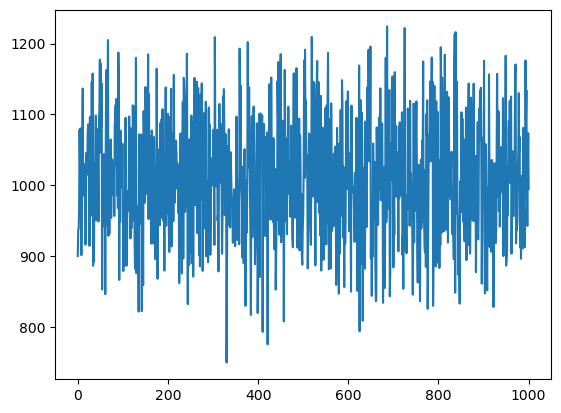

In [64]:
# Ciclo for que corre la simulacion de numeros deseados
for i in range(num_simulations):
    balance2 = [900]
    num_rolls = [0]

    # Corremos las 1000 veces
    while num_rolls[-1] < max_num_rolls:
        iter = roll_dice()
        # Obtiene el costo total
        costo_total = iter[0] + iter[1] + iter[2] + iter[3] + iter[4] + iter[5]
        balance2.append(costo_total)
        num_rolls.append(num_rolls[-1] + 1)

# Graficasmos la muestra
plt.plot(num_rolls, balance2)
plt.show()

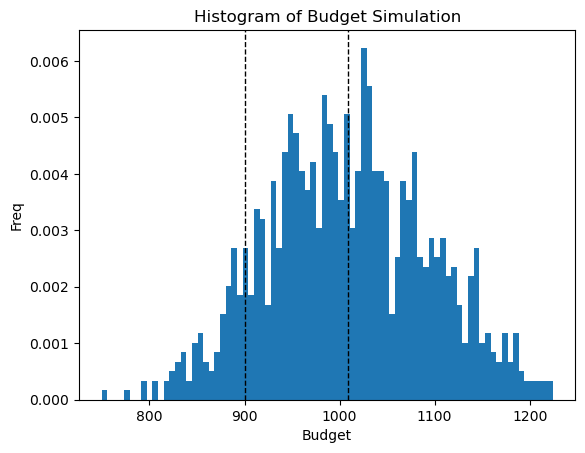

In [68]:
# geenra histograma
np.random.seed(42)
plt.hist(balance2, density=True, bins=80)
plt.ylabel('Freq')
plt.xlabel('Budget')
plt.title('Histogram of Budget Simulation')
plt.axvline(np.mean(balance2), color='k', linestyle='dashed', linewidth=1)
plt.axvline(costo_referencia, color='k', linestyle='dashed', linewidth=1)
plt.show()

In [69]:
total_muestras = balance2.__len__()
# Genera una lista con los numeros menores al costo de referencia en costo_ok
costo_ok = [x for x in balance2 if x < costo_referencia]

# Probabilidad de que sea un total menor al costo de referencia
num_costo_ok = costo_ok.__len__()
prob_costo_ref = num_costo_ok / total_muestras
print(f'La probabilidad de que el costo sea menor al costo de referencia es: {prob_costo_ref:.2f} %')

La probabilidad de que el costo sea menor al costo de referencia es: 0.10 %


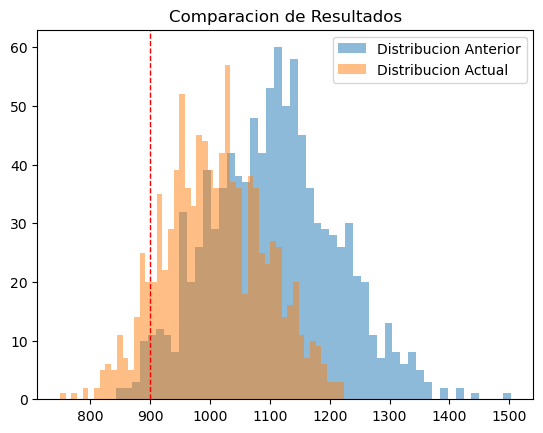

In [70]:
# Graficamos
bins = np.linspace(0, 2000, 10)
plt.hist(balance, bins=50, alpha=0.5, label='Distribucion Anterior')
plt.hist(balance2, bins=50, alpha=0.5, label='Distribucion Actual')
plt.legend(loc='upper right')
plt.title('Comparacion de Resultados')
plt.axvline(costo_referencia, color='r', linestyle='dashed', linewidth=1)
plt.show()

In [72]:
# Como comparar las correlaciones entre cariables y graficarlas
for i in range(num_simulations):
    balance2 = [900]
    num_rolls = [0]

    # Arrays
    cestudios = []
    cdiseno = []
    cingenieria = []
    cimplementacion = []
    cpruebas = []
    caceptacion = []

    while num_rolls[-1] < 1000:
        iter = roll_dice()

        costo_total = iter[0] + iter[1] + iter[2] + iter[3] + iter[4] + iter[5]

        cestudios.append(iter[0])
        cdiseno.append(iter[1])
        cingenieria.append(iter[2])
        cimplementacion.append(iter[3])
        cpruebas.append(iter[4])
        caceptacion.append(iter[5])

        balance2.append(costo_total)
        num_rolls.append(num_rolls[-1] + 1)

In [74]:
cestudios[:5]

[71.05300180143813,
 125.94508951610393,
 97.11035954859442,
 104.69453569659603,
 109.06280683743422]

In [76]:
# Creamos DF para cada uno de los estudios
df1 = pd.DataFrame(cestudios, columns=['Estudios'])
df2 = pd.DataFrame(cdiseno, columns=['Diseño'])
df3 = pd.DataFrame(cingenieria, columns=['Ingenieria'])
df4 = pd.DataFrame(cimplementacion, columns=['Implementacion'])
df5 = pd.DataFrame(cpruebas, columns=['Pruebas'])
df6 = pd.DataFrame(caceptacion, columns=['Aceptacion'])

In [ ]:
# Generamos un DF con la primera columna
df = df1

# Adiciona las columnas de cada variable
df['Diseño'] = df2
df['Ingenieria'] = df3
df['Implementacion'] = df4
df['Pruebas'] = df5
df['Aceptacion'] = df6

In [78]:
df.sample(5)

,Estudios,Diseño,Ingenieria,Implementacion,Pruebas,Aceptacion
132,134.313071,161.203263,191.661740,239.841820,226.148299,246.916746
662,116.811264,151.322393,136.610945,234.634200,240.093235,278.535534
874,113.411115,151.177451,133.606129,138.499356,222.519998,149.073677
609,87.150840,125.081152,139.590901,240.976279,236.366404,136.733141
868,80.861727,124.993706,162.079540,249.171688,219.908819,234.948992


In [80]:
df.corr()

,Estudios,Diseño,Ingenieria,Implementacion,Pruebas,Aceptacion
Estudios,1.000000,-0.010313,0.021263,0.016555,0.035988,-0.030868
Diseño,-0.010313,1.000000,0.009584,-0.012603,0.079926,0.004470
Ingenieria,0.021263,0.009584,1.000000,0.003074,-0.042888,-0.013962
Implementacion,0.016555,-0.012603,0.003074,1.000000,-0.009373,-0.002197
Pruebas,0.035988,0.079926,-0.042888,-0.009373,1.000000,-0.007144
Aceptacion,-0.030868,0.004470,-0.013962,-0.002197,-0.007144,1.000000


In [86]:
print(df.columns)
cols_num = ['Estudios', 'Diseño', 'Ingenieria', 'Implementacion', 'Pruebas', 'Aceptacion']

Index(['Estudios', 'Diseño', 'Ingenieria', 'Implementacion', 'Pruebas',
       'Aceptacion'],
      dtype='object')


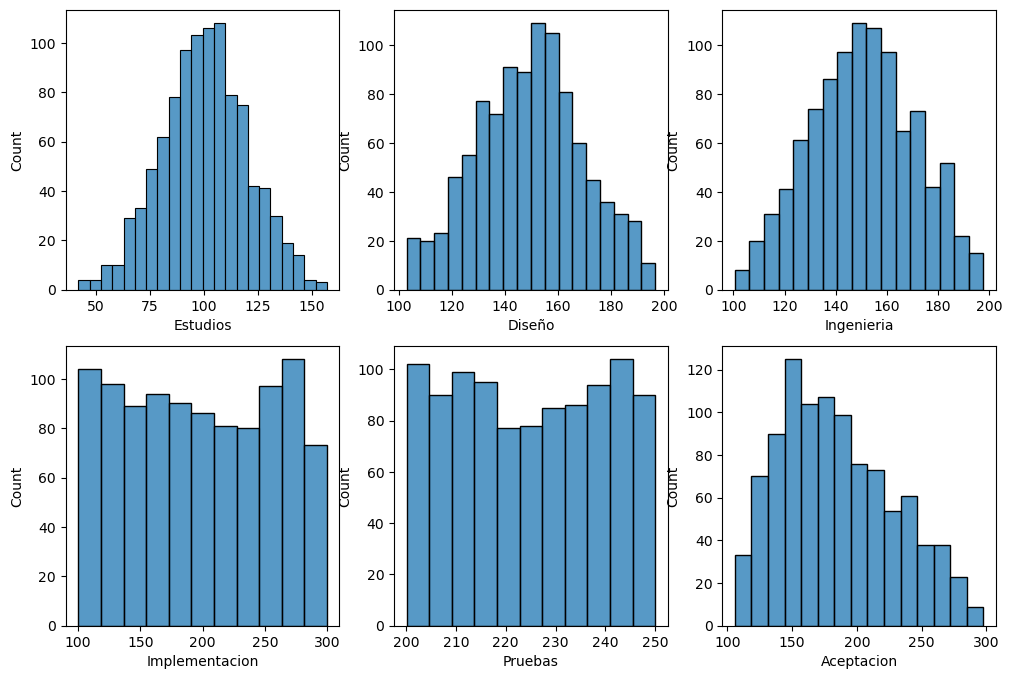

In [94]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,8))
for i, column in enumerate(cols_num):
    sns.histplot(df[column], ax=axes[i//3, i%3], kde=False)
plt.show()